# Trabalhando com imagens

Este notebook mostra como ler e manipular imagens em Python. Também possui instruções para instalar as bibliotecas necessárias e para baixar o conjunto de imagens que será usado nas aulas.

## Passos iniciais

O conjunto de imagens está disponível em:

https://www.dropbox.com/scl/fi/g5cix71avcekuicienkv0/pvd_images.zip?rlkey=kkuth4qfoyjshxi4s939ixlg4&dl=1

Baixe o arquivo e descompacte-o.

**Instalação das bibliotecas:**

Serão utilizadas as bibliotecas `PIL` e `OpenCV` nas aulas. Para instalar:

Usando conda:

```
conda install -c conda-forge pillow opencv
```

Usando pip:

```
pip install pillow opencv-contrib-python
```

In [45]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Diretório raiz das imagens. Altere conforme necessário.
images_dir = Path("../dados/pvd_images/images")
# Lista com o caminho de todas as imagens no diretório
all_paths = list(images_dir.iterdir())
print(f"{len(all_paths)} arquivos no diretório")

1845 arquivos no diretório


In [46]:
# Caminho de uma imagem específica
image_path = images_dir / "26yfp.jpeg"
print(image_path)

../dados/pvd_images/images/26yfp.jpeg


## Abrindo uma imagem

A biblioteca `PIL` (instalada com o nome `pillow`) é a forma mais direta de abrir uma imagem.

In [47]:
image = Image.open(image_path)
print(image)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480 at 0x7FBA52373890>


Repare que `Image.open` devolve um objeto, e não os pixels.

A abertura lê apenas o **cabeçalho** do arquivo, que informa o formato e as
dimensões da imagem. Os pixels só são decodificados quando alguém realmente pede por eles. Isso é
importante: percorrer dez mil arquivos só para descobrir o tamanho de cada um custa quase
nada, porque nenhum deles chega a ser decodificado.

## Mostrar na tela

Num notebook, se a última linha da célula for uma variável do tipo `Image`, o Jupyter Notebook mostra a imagem na tela.

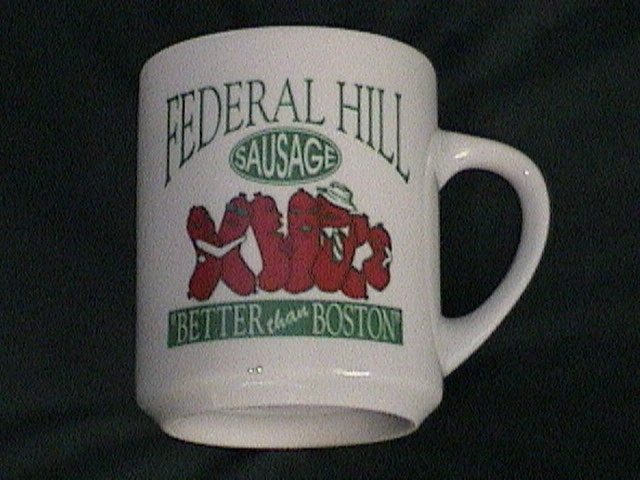

In [48]:
image

Outra forma de mostrar a imagem é pelo `matplotlib`:

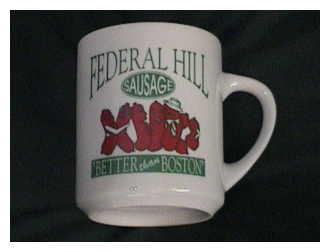

In [49]:
fig, ax = plt.subplots(figsize=(4, 3.6))
ax.imshow(image)
ax.axis("off")
plt.show()

As duas formas mostram a mesma coisa, com uma diferença: o `imshow` coloca a imagem dentro de
um sistema de coordenadas, em que o eixo horizontal é a coluna e o vertical é a linha, com a origem
no canto **superior** esquerdo. O comando `ax.axis("off")` esconde os eixos.

## Informações da imagem

In [50]:
size_kb = image_path.stat().st_size / 1024

print(f"formato ....... {image.format}")
print(f"modo .......... {image.mode}")
print(f"dimensões ..... {image.size}  (largura, altura)")
print(f"tamanho ....... {size_kb:.0f} KB em disco")

formato ....... JPEG
modo .......... RGB
dimensões ..... (640, 480)  (largura, altura)
tamanho ....... 89 KB em disco


O **formato** é como os dados estão codificados dentro do arquivo: `JPEG`, `PNG`, `WEBP`. Ele
é lido dos primeiros bytes do arquivo, e não da extensão do nome.

O **modo** é como os pixels são representados: `RGB` são três canais de cor, `L` é um canal de
cinza, e existem vários outros que veremos adiante.

Cuidado com a ordem em `size`: o PIL devolve `(largura, altura)`, enquanto o `numpy` usa
`(linhas, colunas)`, ou seja `(altura, largura)`.

## De imagem para array

Para realizar cálculos com a imagem, precisamos transformar o objeto em um array do `numpy`. 

In [51]:
array = np.asarray(image)

print(f"shape ......... {array.shape}   (linhas, colunas, canais)")
print(f"dtype ......... {array.dtype}")
print(f"faixa ......... {array.min()} a {array.max()}")
print(f"memória ....... {array.nbytes / 1024:.0f} KB")

shape ......... (480, 640, 3)   (linhas, colunas, canais)
dtype ......... uint8
faixa ......... 0 a 252
memória ....... 900 KB


O array tem três eixos. O primeiro é a linha, o segundo é a coluna e o terceiro é o canal de
cor. Cada valor é um inteiro de 8 bits sem sinal, então vai de 0 a 255.

Compare a memória do array com o tamanho do arquivo em disco: o JPEG guarda a mesma imagem
comprimida, e a descompressão acontece na hora de abrir.

In [52]:
# Um pixel é um vetor com os três valores: a quantidade de vermelho, verde e azul
print(f"pixel (0, 0) ......... {array[0, 0]}")

# Uma linha inteira é uma matriz de (colunas, canais)
print(f"linha 100 ............ {array[100].shape}")

# Podemos recortar uma região da imagem
crop = array[150:300, 170:350]
print(f"recorte .............. {crop.shape}")

pixel (0, 0) ......... [16 17 21]
linha 100 ............ (640, 3)
recorte .............. (150, 180, 3)


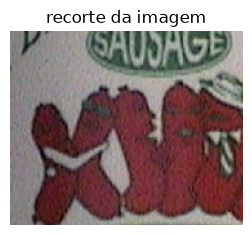

In [53]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(crop)
ax.set_title("recorte da imagem")
ax.axis("off")
plt.show()

## Os canais de cor

Separar os canais ajuda a entender o que cada um representa.

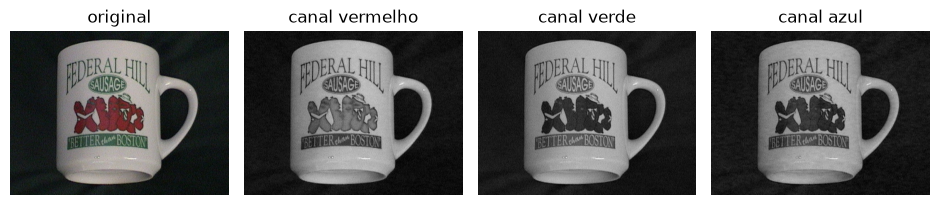

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(9.5, 2.9))

axes[0].imshow(array)
axes[0].set_title("original")

for index, name in enumerate(["vermelho", "verde", "azul"]):
    axes[index+1].imshow(array[:, :, index], cmap="gray", vmin=0, vmax=255)
    axes[index+1].set_title(f"canal {name}")

for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

Cada canal é uma matriz que mostra o quanto de vermelho, de verde ou de
azul existe em cada posição. Não é uma imagem colorida, é um mapa de intensidade, e por isso
foi desenhado em tons de cinza, em que mais claro significa mais daquele canal.

Repare no logotipo vermelho da caneca. Ele é claro no canal vermelho, mas escuro nos outros dois. 

## Nível de cinza

Converter para cinza descarta a cor e mantém a luminosidade.

In [55]:
gray = image.convert("L")
gray_array = np.asarray(gray)

print(f"modo .......... {gray.mode}")
print(f"shape ......... {gray_array.shape}   (sem o eixo de canal)")
print(f"memória ....... {gray_array.nbytes / 1024:.0f} KB, um terço do colorido")

modo .......... L
shape ......... (480, 640)   (sem o eixo de canal)
memória ....... 300 KB, um terço do colorido


O **histograma** das intensidades resume a imagem inteira em uma curva. Ele será útil na
triagem: uma imagem escura demais, ou sem contraste, tem um histograma com formato bem
característico.

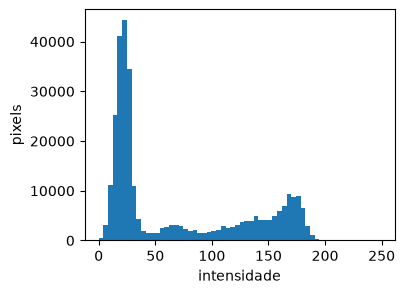

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

ax.hist(gray_array.ravel(), bins=60)
ax.set_xlabel("intensidade"); ax.set_ylabel("pixels")
plt.show()

## Redimensionamento

Para redimensionar imagens, podemos redimensionar para um tamanho fixo, ou preservar a proporção (ratio). 

In [57]:
# Proporção da imagem (largura / altura)
ratio = array.shape[1] / array.shape[0]

# Nova dimensão da imagem
new_size = 224
# Redimensiona para uma imagem quadrada (224 x 224)
resized_equal = image.resize((new_size, new_size))
# Redimensiona para a largura de 224. A altura é calculada para manter a proporção da imagem original. 
resized_ratio = image.resize((new_size, int(new_size/ratio)))

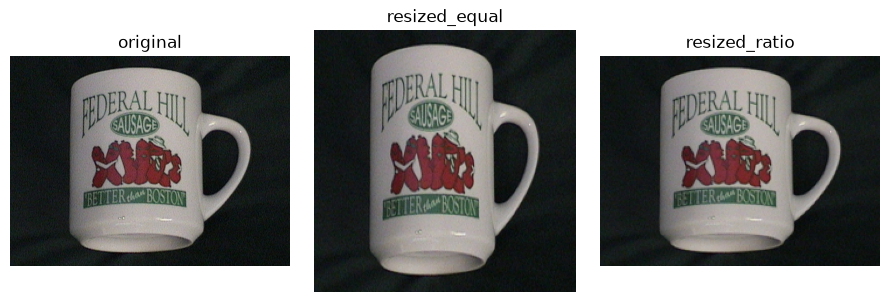

In [58]:
images = [("original", image), ("resized_equal", resized_equal), ("resized_ratio", resized_ratio)]

fig, axes = plt.subplots(1, 3, figsize=(9, 3.0))
for ax, (title, panel_image) in zip(axes, images):
    ax.imshow(panel_image)
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout(); plt.show()

## O custo do formato

Gravar a mesma imagem em formatos diferentes dá arquivos de tamanhos muito diferentes, e nem
todos guardam os mesmos pixels.

In [59]:
import tempfile

def save_image(image, name, quality=None):
    """Salva imagem em um diretório temporário e retorna o tamanho do arquivo em KB."""
    work_dir = Path(tempfile.mkdtemp())
    image.save(work_dir / name, quality=quality)

    size = (work_dir / name).stat().st_size / 1024

    return size

size = save_image(image, "copia.png")
print(f"{size:6.0f} KB")

size = save_image(image, "copia_q95.jpeg", quality=95)
print(f"{size:6.0f} KB")

size = save_image(image, "copia_q20.jpeg", quality=20)
print(f"{size:6.0f} KB")

   454 KB
   103 KB
    13 KB


O **PNG** é um formato sem perda: os pixels que saem são exatamente os que entraram. O
**JPEG** é um formato com perda, e o parâmetro `quality` controla quanto ele descarta.

A diferença entre uma mesma imagem comprimida em JPEG com diferentes qualidades ou salva em PNG pode não ser perceptível a olho nu, mas os valores da imagem mudam.